# E01 - Baseline Conversion Ranking

This notebook builds a clean baseline for lead ranking on the Hillstrom email dataset.

The business problem is not ordinary classification. A sales or marketing team usually has a fixed contact capacity, so the useful question is:

> If we can contact only the top K leads, does the model put more actual converters near the top than random selection?

This experiment estimates observed conversion probability, not causal uplift. It answers who is likely to convert, not who converts because of an intervention.

## Experiment Design

For each lead/customer:

- `X`: pre-outcome features
- `Y`: observed binary conversion outcome
- `score`: model-estimated probability of conversion
- `K`: sales or campaign capacity

The baseline policy sorts leads by predicted conversion score and selects the top K.

Because conversion is rare, we focus on ranking metrics instead of accuracy:

- precision at K
- recall/capture at K
- lift at K versus random
- cumulative gains curve
- lift curve
- precision-recall curve and PR-AUC
- ROC curve and ROC-AUC

## To Do / Future Updates
- [ ] Fix log and raw features
- [X] Add BRF
- [X] Shallower RF
- [X] Cross Val
- [ ] Decible Analysis
- [X] Change eval metric to aucpr
- [ ] Feature Importance
- [ ] Error Analysis
- [ ] Correlation & Feature Eng.

## Setup

The notebook expects `src/data/hillstrom.csv` to exist. If it is missing, the loader tries to download the dataset with TensorFlow Datasets.

In [1]:
!pip install --quiet pandas numpy matplotlib seaborn scikit-learn tensorflow tensorflow-datasets xgboost imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from imblearn.ensemble import BalancedRandomForestClassifier

from scipy.stats import randint, uniform

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.base import clone

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_COL = "conversion"
K_VALUES = [100, 200, 300, 400, 500, 750, 1000]
N_SPLITS = 5

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

In [3]:
cwd = Path.cwd()

if (cwd / "src" / "data" / "hillstrom.csv").exists():
    BASE_DIR = cwd
elif (cwd.parent / "src" / "data" / "hillstrom.csv").exists():
    BASE_DIR = cwd.parent
else:
    BASE_DIR = cwd.parent if cwd.name == "experiments" else cwd

DATA_DIR = BASE_DIR / "src" / "data"
DATA_PATH = DATA_DIR / "hillstrom.csv"

print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")

Base directory: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring
Data path: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\src\data\hillstrom.csv


## Load Data

The Hillstrom data comes from a randomized email marketing experiment. The original columns include customer history, channel, zip code, treatment segment, visit, spend, and conversion.

For this baseline, `conversion` is the target.

In [4]:
def load_hillstrom_csv(path):
    if path.exists():
        return pd.read_csv(path)

    try:
        import tensorflow_datasets as tfds
    except ImportError as exc:
        raise FileNotFoundError(
            f"{path} does not exist, and tensorflow_datasets is not installed."
        ) from exc

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    hillstrom_ds = tfds.load("hillstrom", split=["train"], as_supervised=False)
    rows = []

    for sample in tfds.as_numpy(hillstrom_ds[0]):
        rows.append(
            {
                "channel": sample["channel"].decode("utf-8"),
                "conversion": int(sample["conversion"]),
                "history": float(sample["history"]),
                "history_segment": sample["history_segment"].decode("utf-8"),
                "mens": int(sample["mens"]),
                "newbie": int(sample["newbie"]),
                "recency": int(sample["recency"]),
                "segment": sample["segment"].decode("utf-8"),
                "spend": float(sample["spend"]),
                "visit": int(sample["visit"]),
                "womens": int(sample["womens"]),
                "zip_code": sample["zip_code"].decode("utf-8"),
            }
        )

    frame = pd.DataFrame(rows)
    frame.to_csv(path, index=False)
    return frame


hillstrom_df = load_hillstrom_csv(DATA_PATH)

print(hillstrom_df.shape)
display(hillstrom_df.head())

(64000, 12)


,channel,conversion,history,history_segment,mens,newbie,recency,segment,spend,visit,womens,zip_code
0,Multichannel,0,328.160004,3) $200 - $350,0,0,3,Mens E-Mail,0.0,0,1,Urban
1,Web,0,70.860001,1) $0 - $100,1,0,9,No E-Mail,0.0,0,0,Rural
2,Phone,0,94.250000,1) $0 - $100,1,1,12,No E-Mail,0.0,0,0,Surburban
3,Web,0,304.350006,3) $200 - $350,0,0,5,Mens E-Mail,0.0,0,1,Urban
4,Web,0,222.860001,3) $200 - $350,1,0,4,Mens E-Mail,0.0,1,0,Urban


## Basic Data Checks

Before modeling, check shape, missingness, target imbalance, and simple conversion rates by major groups. This is not full EDA, but it catches the most important modeling risks.

In [5]:
print("DataFrame Descriptive Statistics:")
display(hillstrom_df.describe(include="all").T)

print("\n")
print("=================")
print("\n")
print("Missing Values Summary:")

display(hillstrom_df.isna().sum())

DataFrame Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
channel,64000,3,Web,28217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conversion,64000.0,NaN,NaN,NaN,0.009031,0.094604,0.0,0.0,0.0,0.0,1.0
history,64000.0,NaN,NaN,NaN,242.085656,256.158608,29.99,64.660004,158.110001,325.657494,3345.929932
history_segment,64000,7,1) $0 - $100,22970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mens,64000.0,NaN,NaN,NaN,0.551031,0.497393,0.0,0.0,1.0,1.0,1.0
newbie,64000.0,NaN,NaN,NaN,0.50225,0.499999,0.0,0.0,1.0,1.0,1.0
recency,64000.0,NaN,NaN,NaN,5.763734,3.507592,1.0,2.0,6.0,9.0,12.0
segment,64000,3,Womens E-Mail,21387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spend,64000.0,NaN,NaN,NaN,1.050908,15.036448,0.0,0.0,0.0,0.0,499.0
visit,64000.0,NaN,NaN,NaN,0.146781,0.35389,0.0,0.0,0.0,0.0,1.0






Missing Values Summary:


channel            0
conversion         0
history            0
history_segment    0
mens               0
newbie             0
recency            0
segment            0
spend              0
visit              0
womens             0
zip_code           0
dtype: int64

In [6]:
class_balance = (
    hillstrom_df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
class_balance["share"] = class_balance["count"] / len(hillstrom_df)

display(class_balance)
print(f"Base conversion rate: {hillstrom_df[TARGET_COL].mean():.4%}")

,conversion,count,share
0,0,63422,0.990969
1,1,578,0.009031


Base conversion rate: 0.9031%


In [7]:
def conversion_rate_table(frame, group_col, target_col=TARGET_COL):
    return (
        frame.groupby(group_col)[target_col]
        .agg(count="count", conversions="sum", conversion_rate="mean")
        .sort_values("conversion_rate", ascending=False)
    )


for col in ["segment", "channel", "zip_code", "history_segment", "mens", "womens", "newbie"]:
    print(f"Conversion rate by {col}")
    display(conversion_rate_table(hillstrom_df, col))

Conversion rate by segment


,count,conversions,conversion_rate
segment,,,
Mens E-Mail,21307,267,0.012531
Womens E-Mail,21387,189,0.008837
No E-Mail,21306,122,0.005726


Conversion rate by channel


,count,conversions,conversion_rate
channel,,,
Multichannel,7762,98,0.012626
Web,28217,263,0.009321
Phone,28021,217,0.007744


Conversion rate by zip_code


...

,count,conversions,conversion_rate
mens,,,
1,35266,326,0.009244
0,28734,252,0.008770


Conversion rate by womens


,count,conversions,conversion_rate
womens,,,
1,35182,356,0.010119
0,28818,222,0.007704


Conversion rate by newbie


,count,conversions,conversion_rate
newbie,,,
0,31856,322,0.010108
1,32144,256,0.007964


## Targeted EDA: Shape, Skew, and Interactions

The first modeling risk is that conversion is rare, so small changes in ranking can look noisy. The second risk is that some features are skewed or only useful through interactions.

This section checks:

- the distribution of customer history before and after a log transform
- conversion rate by history decile
- conversion-rate heatmaps for simple feature interactions
- treatment-arm conversion rates for context, while keeping treatment out of the baseline model

In [8]:
eda_df = hillstrom_df.copy()

eda_df["log_history"] = np.log1p(eda_df["history"])
eda_df["history_decile"] = pd.qcut(
    eda_df["history"],
    q=10,
    duplicates="drop",
)
eda_df["history_decile_label"] = (eda_df["history_decile"]
                                      .apply(
        lambda x: f"({x.left:.2f}, {x.right:.2f}]"
    )
                                  .astype(str)
)
eda_df["recency_bucket"] = pd.cut(
    eda_df["recency"],
    bins=[0, 3, 6, 9, 12],
    labels=["1-3", "4-6", "7-9", "10-12"],
    include_lowest=True,
)

history_decile_summary = (
    eda_df.groupby("history_decile", observed=True)[TARGET_COL]
    .agg(count="count", conversions="sum", conversion_rate="mean")
    .reset_index()
)
history_decile_summary["history_decile"] = (
    history_decile_summary["history_decile"]
    .apply(
        lambda x: f"({x.left:.2f}, {x.right:.2f}]"
    )
)

display(history_decile_summary)

,history_decile,count,conversions,conversion_rate
0,"(29.99, 50.30]",12800,87,0.006797
1,"(50.30, 80.19]",6400,49,0.007656
2,"(80.19, 115.28]",6401,45,0.007030
3,"(115.28, 158.11]",6400,32,0.005000
4,"(158.11, 210.81]",6400,58,0.009062
5,"(210.81, 281.21]",6400,61,0.009531
6,"(281.21, 382.03]",6399,77,0.012033
7,"(382.03, 561.19]",6400,74,0.011562
8,"(561.19, 3345.93]",6400,95,0.014844


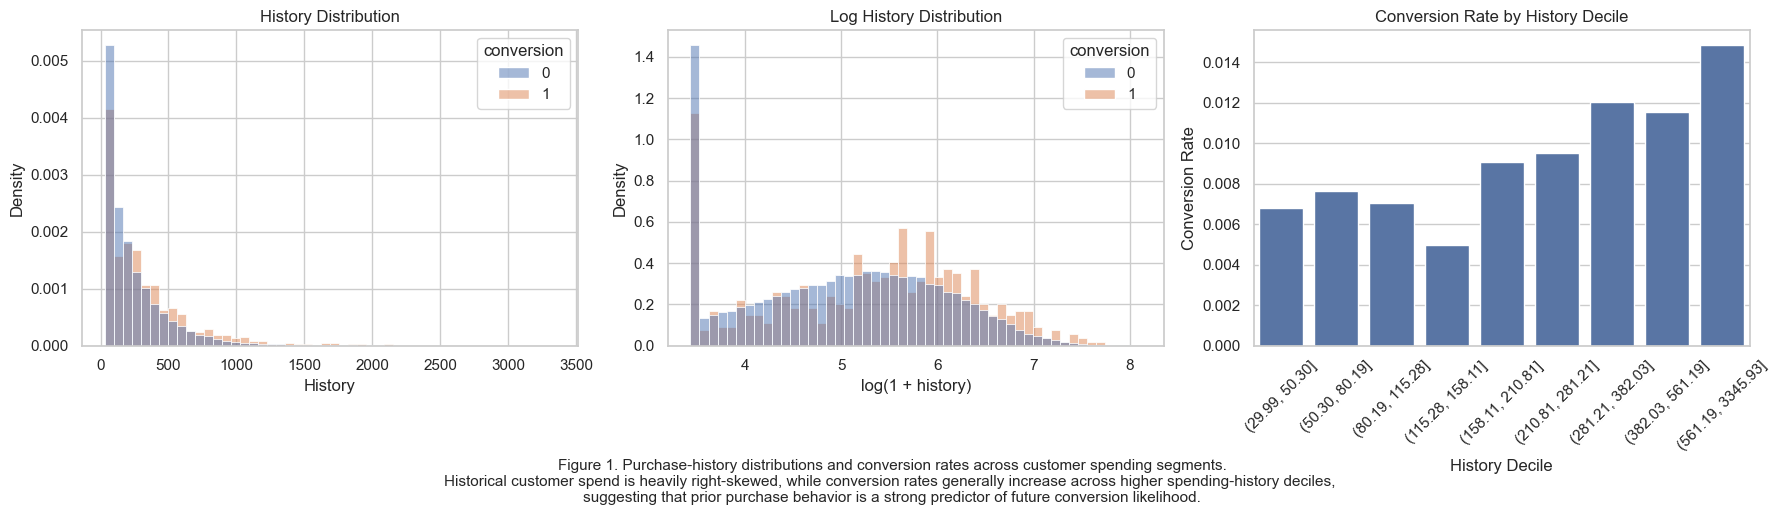

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=eda_df,
    x="history",
    bins=50,
    hue=TARGET_COL,
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("History Distribution")
axes[0].set_xlabel("History")

sns.histplot(
    data=eda_df,
    x="log_history",
    bins=50,
    hue=TARGET_COL,
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Log History Distribution")
axes[1].set_xlabel("log(1 + history)")

sns.barplot(
    data=history_decile_summary,
    x="history_decile",
    y="conversion_rate",
    ax=axes[2],
)
axes[2].set_title("Conversion Rate by History Decile")
axes[2].set_xlabel("History Decile")
axes[2].set_ylabel("Conversion Rate")
axes[2].tick_params(axis="x", rotation=45)


fig.text(
    0.5,
    -0.02,
    (
       "Figure 1. Purchase-history distributions and conversion rates across customer spending segments.\n"
        "Historical customer spend is heavily right-skewed, "
        "while conversion rates generally increase across higher spending-history deciles, \n"
        "suggesting that prior purchase behavior is a strong predictor of future conversion likelihood."
    ),
    ha="center",
    fontsize=11
)
plt.tight_layout()
plt.show()

### Observations (Figure 1)

- Customer spending history is strongly right-skewed, with most users concentrated in low-spend ranges and a small number of high-value customers forming a long tail.

- After log transformation, converters exhibit a modest rightward shift in the history distribution, indicating that customers with stronger prior engagement tend to convert more frequently.

- Conversion rates generally increase across higher spending-history deciles, suggesting that prior purchasing behavior is an important predictive signal for future conversion propensity.

- This pattern is consistent with mechanisms such as customer loyalty, repeat-purchase behavior, and retention effects, although the analysis remains correlational rather than causal.

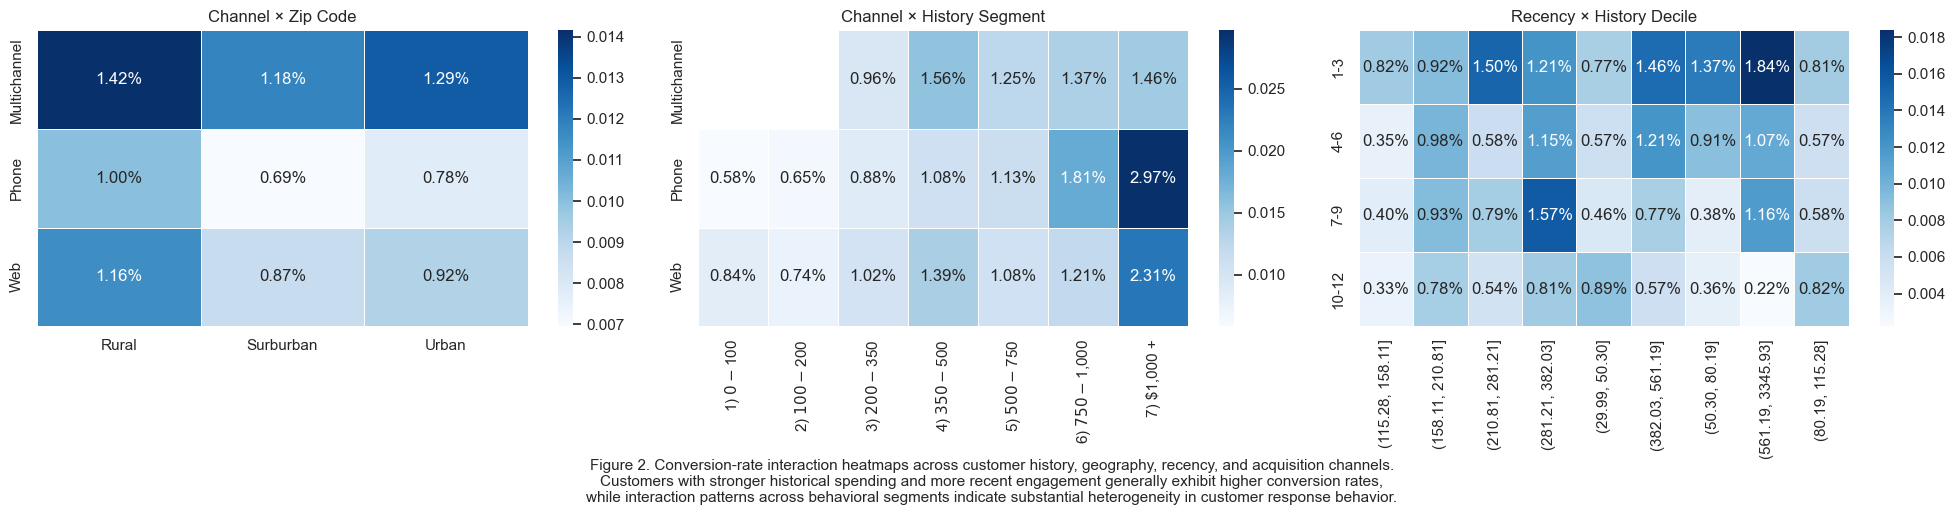

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# =========================
# Heatmap 1
# =========================

heatmap_1 = eda_df.pivot_table(
    index="channel",
    columns="zip_code",
    values=TARGET_COL,
    aggfunc="mean",
    observed=True,
)

sns.heatmap(
    heatmap_1,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Channel × Zip Code"
)

# =========================
# Heatmap 2
# =========================

heatmap_2 = eda_df.pivot_table(
    index="channel",
    columns="history_segment",
    values=TARGET_COL,
    aggfunc="mean",
    observed=True,
)

sns.heatmap(
    heatmap_2,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title(
    "Channel × History Segment"
)

# =========================
# Heatmap 3
# =========================

heatmap_3 = eda_df.pivot_table(
    index="recency_bucket",
    columns="history_decile_label",
    values=TARGET_COL,
    aggfunc="mean",
    observed=True,
)

sns.heatmap(
    heatmap_3,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[2]
)

axes[2].set_title(
    "Recency × History Decile"
)

# =========================
# Shared formatting
# =========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

# =========================
# Figure caption
# =========================

fig.text(
    0.5,
    -0.02,
    (
        "Figure 2. Conversion-rate interaction heatmaps across customer history, geography, recency, and acquisition channels.\n"
        "Customers with stronger historical spending and more recent engagement generally exhibit higher conversion rates,\n"
        "while interaction patterns across behavioral segments indicate substantial heterogeneity in customer response behavior."
    ),
    ha="center",
    fontsize=11
)

plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

plt.show()

,segment,channel,count,conversions,conversion_rate
0,Mens E-Mail,Multichannel,2577,44,0.017074
6,Womens E-Mail,Multichannel,2579,36,0.013959
2,Mens E-Mail,Web,9490,123,0.012961
1,Mens E-Mail,Phone,9240,100,0.010823
8,Womens E-Mail,Web,9354,86,0.009194
7,Womens E-Mail,Phone,9454,67,0.007087
3,No E-Mail,Multichannel,2606,18,0.006907
5,No E-Mail,Web,9373,54,0.005761
4,No E-Mail,Phone,9327,50,0.005361


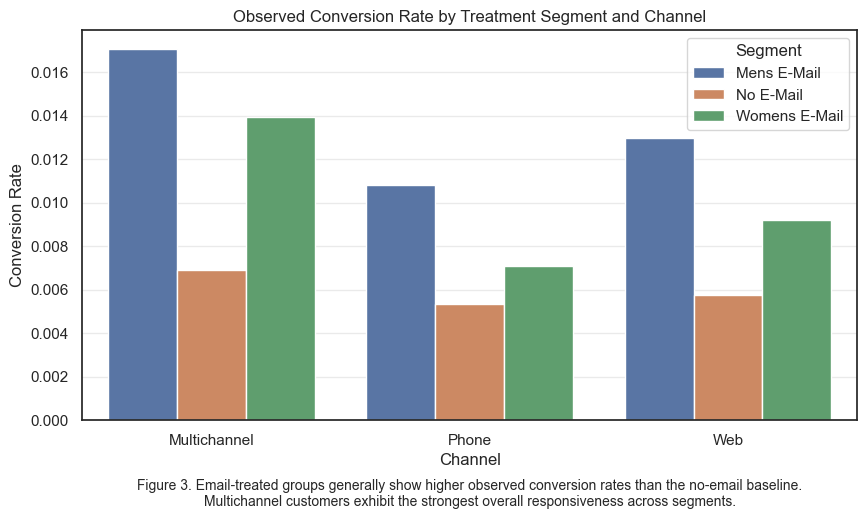

In [11]:
treatment_context = (
    eda_df.groupby(["segment", "channel"])[TARGET_COL]
    .agg(count="count", conversions="sum", conversion_rate="mean")
    .reset_index()
)

display(treatment_context.sort_values("conversion_rate", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=treatment_context,
    x="channel",
    y="conversion_rate",
    hue="segment",
    ax=ax,
)

ax.set_title("Observed Conversion Rate by Treatment Segment and Channel")

ax.text(
    0.5,
    -0.22,
    (
        "Figure 3. Email-treated groups generally show higher observed conversion rates than the no-email baseline.\n"
        "Multichannel customers exhibit the strongest overall responsiveness across segments."
    ),
    ha="center",
    fontsize=10,
    transform=ax.transAxes,
)

ax.set_xlabel("Channel")
ax.set_ylabel("Conversion Rate")
ax.legend(title="Segment")
ax.grid(True, axis="y", alpha=0.4)

fig.subplots_adjust(bottom=0.10)

plt.show()

### Observations (Figure 2)
### Observations (Figure 3)

## Leakage Decisions and Feature Engineering

A baseline conversion ranker should only use information available before the outcome is observed.

For this dataset:

- `spend` is post-conversion value, so it is excluded.
- `visit` is post-campaign behavior and strongly leaks conversion, so it is excluded.
- `segment` is the randomized email treatment assignment. We exclude it from this simple baseline so the model ranks customers by pre-treatment features rather than by campaign arm.
- `history_segment` is converted into an ordinal `spend_level` feature.

The engineered feature set adds simple, interpretable transformations:

- `log_history` for skewed purchase history
- history-recency interactions
- newbie-history interaction
- product-affinity flags from `mens` and `womens`
- categorical interaction labels such as `channel_zip_code` and `channel_spend_level`

In [12]:
def add_hillstrom_features(frame):

    out = frame.copy()

    # =====================================================
    # SPEND / VALUE FEATURES
    # =====================================================

    # Extract ordinal spend segment
    out["spend_level"] = (
        out["history_segment"]
        .str.extract(r"(\d+)")
        .astype(float)
    )

    # Log spend history
    out["log_history"] = np.log1p(
        out["history"]
    )

    # =====================================================
    # RECENCY INTERACTIONS
    # =====================================================

    # Prefer log-history interaction instead of raw history
    out["log_history_x_recency"] = (
        out["log_history"]
        * out["recency"]
    )

    out["history_x_recency"] = (
        out["history"]
        * out["recency"]
    )

    # New users with spend history
    out["newbie_x_log_history"] = (
        out["newbie"]
        * out["log_history"]
    )

    # =====================================================
    # GENDER AFFINITY FEATURES
    # =====================================================

    out["mens_only"] = (
        (out["mens"] == 1)
        & (out["womens"] == 0)
    ).astype(int)

    out["womens_only"] = (
        (out["mens"] == 0)
        & (out["womens"] == 1)
    ).astype(int)

    out["mens_womens_both"] = (
        (out["mens"] == 1)
        & (out["womens"] == 1)
    ).astype(int)


    # =====================================================
    # CATEGORICAL INTERACTIONS
    # =====================================================

    # Useful interaction:
    # acquisition/source behavior by geography
    out["channel_zip_code"] = (
        out["channel"].astype(str)
        + "_"
        + out["zip_code"].astype(str)
    )
    out["channel_spend_level"] = (
        out["channel"].astype(str)
        + "_level_"
        + out["spend_level"].astype(str)
    )

    return out


# =========================================================
# FEATURE ENGINEERING
# =========================================================

model_df = add_hillstrom_features(
    hillstrom_df
)

# =========================================================
# REMOVE LEAKAGE / REDUNDANT FEATURES
# =========================================================

leakage_or_non_feature_cols = [

    # Targets / leakage
    "spend",
    "visit",
    "segment",

    # Raw versions replaced by transformed features
    "history_segment",

    "history",
    "history_x_recency",
]

model_df = model_df.drop(
    columns=leakage_or_non_feature_cols,
    errors="ignore",
)

# =========================================================
# FEATURE GROUPS
# =========================================================

# Removing raw history and history x recency from feature set increased XGBoost & RF performance, but impacted LR negatively.

CONTINUOUS_COLS = [
    # "history",
    "log_history",
    "recency",
    "spend_level",
    "log_history_x_recency",
    "newbie_x_log_history",
    # "history_x_recency"
]

BINARY_COLS = [
    "mens",
    "womens",
    "newbie",
    "mens_only",
    "womens_only",
    "mens_womens_both",
]

CAT_COLS = [
    "channel",
    "zip_code",
    "channel_zip_code",
    "channel_spend_level"
]

FEATURE_COLS = (
    CONTINUOUS_COLS
    + BINARY_COLS
    + CAT_COLS
)

# =========================================================
# FINAL DISPLAY
# =========================================================

print(
    f"Number of engineered features: {len(FEATURE_COLS)}"
)

display(
    model_df[
        FEATURE_COLS + [TARGET_COL]
    ].head()
)

Number of engineered features: 15


,log_history,recency,spend_level,log_history_x_recency,newbie_x_log_history,mens,womens,newbie,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level,conversion
0,5.796544,3,3.0,17.389632,0.000000,0,1,0,0,1,0,Multichannel,Urban,Multichannel_Urban,Multichannel_level_3.0,0
1,4.274720,9,1.0,38.472478,0.000000,1,0,0,1,0,0,Web,Rural,Web_Rural,Web_level_1.0,0
2,4.556505,12,1.0,54.678060,4.556505,1,0,1,1,0,0,Phone,Surburban,Phone_Surburban,Phone_level_1.0,0
3,5.721459,5,3.0,28.607293,0.000000,0,1,0,0,1,0,Web,Urban,Web_Urban,Web_level_3.0,0
4,5.411021,4,3.0,21.644083,0.000000,1,0,0,1,0,0,Web,Urban,Web_Urban,Web_level_3.0,0


## Train/Test Split

The dataset has no timestamp, so this experiment uses a stratified random split. In production CRM data, prefer a time-based split so the test set represents future leads.

In [13]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=model_df[TARGET_COL],
)

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.4%}")
print(f"Test conversion rate: {y_test.mean():.4%}")

Train shape: (51200, 15)
Test shape: (12800, 15)
Train conversion rate: 0.9023%
Test conversion rate: 0.9062%


## Preprocessing and Models

Preprocessing differs by model family.

For logistic regression:

- continuous numeric features are median-imputed and standardized
- binary flags are imputed without scaling
- categorical features are one-hot encoded

For tree models:

- continuous numeric features are imputed but not scaled
- binary flags are imputed without scaling
- categorical features are one-hot encoded

Scaling matters for logistic regression because features such as `history` and `history_x_recency` live on much larger numeric scales than binary flags. Scaling is usually unnecessary for random forests and boosted trees.

In [14]:
scaled_continuous_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

unscaled_continuous_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

binary_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", scaled_continuous_transformer, CONTINUOUS_COLS),
        ("binary", binary_transformer, BINARY_COLS),
        ("cat", categorical_transformer, CAT_COLS),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", unscaled_continuous_transformer, CONTINUOUS_COLS),
        ("binary", binary_transformer, BINARY_COLS),
        ("cat", categorical_transformer, CAT_COLS),
    ]
)

In [15]:
model_specs = {

    "Logistic Regression": (
        LogisticRegression(
            max_iter=4000,
            class_weight="balanced",
            solver="saga",
            penalty="l2",
            C=1.0,
            random_state=RANDOM_STATE,
        ),
        lr_preprocessor,
    ),

    "Random Forest": (
        RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        tree_preprocessor,
    ),

    "BRF": (
        BalancedRandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            replacement=True,
            sampling_strategy="all",
            bootstrap=False,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        tree_preprocessor,
    ),
}

try:

    from xgboost import XGBClassifier

    scale_pos_weight = (
        y_train.value_counts()[0]
        / y_train.value_counts()[1]
    )

    model_specs["XGBoost"] = (
        XGBClassifier(
            objective="binary:logistic",

            n_estimators=400,
            max_depth=5,
            learning_rate=0.03,

            subsample=0.8,
            colsample_bytree=0.8,

            min_child_weight=5,
            gamma=0.1,

            reg_alpha=0.1,
            reg_lambda=1.0,

            eval_metric="aucpr",

            tree_method="hist",

            scale_pos_weight=scale_pos_weight,

            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        tree_preprocessor,
    )

except ImportError:
    print("xgboost not installed")
    
pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    for name, (model, preprocessor) in model_specs.items()
}

list(pipelines.keys())

['Logistic Regression', 'Random Forest', 'BRF', 'XGBoost']

In [16]:
for model_name, pipeline in pipelines.items():
    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)

print("Done.")

Training Logistic Regression...
Training Random Forest...
Training BRF...
Training XGBoost...
Done.


In [17]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

results = []
oof_predictions = {}

for model_name, model in pipelines.items():

    pipeline = Pipeline([
        ("preprocessor", clone(model.named_steps["preprocessor"])),
        ("model", clone(model.named_steps["model"]))
    ])

    preds = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    oof_predictions[model_name] = preds

    aucpr = average_precision_score(y_train, preds)
    rocauc = roc_auc_score(y_train, preds)

    results.append({
        "model": model_name,
        "aucpr": aucpr,
        "roc_auc": rocauc,
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("aucpr", ascending=False)

results_df

,model,aucpr,roc_auc
3,XGBoost,0.012456,0.533887
2,BRF,0.012000,0.584161
1,Random Forest,0.010845,0.542748
0,Logistic Regression,0.010506,0.535443


## Classification Report as a Sanity Check

The classification report is useful for a quick diagnostic, but it is not the main evaluation. With rare conversions, thresholded classification metrics can be misleading.

The ranking sections below are the important part of this experiment.

In [18]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

for model_name, pipeline in pipelines.items():
    print(f"\n{model_name}")
    print(classification_report(y_test, pipeline.predict(X_test), digits=4))


Logistic Regression
              precision    recall  f1-score   support

           0     0.9918    0.7401    0.8477     12684
           1     0.0114    0.3276    0.0220       116

    accuracy                         0.7364     12800
   macro avg     0.5016    0.5339    0.4349     12800
weighted avg     0.9829    0.7364    0.8402     12800


Random Forest
              precision    recall  f1-score   support

           0     0.9915    0.9422    0.9662     12684
           1     0.0187    0.1207    0.0324       116

    accuracy                         0.9348     12800
   macro avg     0.5051    0.5315    0.4993     12800
weighted avg     0.9827    0.9348    0.9578     12800


BRF
              precision    recall  f1-score   support

           0     0.9930    0.6687    0.7992     12684
           1     0.0132    0.4828    0.0256       116

    accuracy                         0.6670     12800
   macro avg     0.5031    0.5757    0.4124     12800
weighted avg     0.9841    0.6670

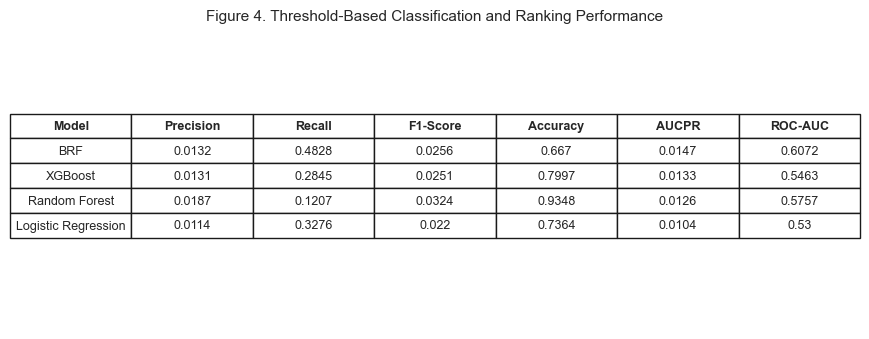

In [19]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score,
)

results = []

for model_name, pipeline in pipelines.items():

    # Binary predictions
    y_pred = pipeline.predict(X_test)

    # Probabilities for ranking metrics
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    results.append({
        "Model": model_name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "Accuracy": report["accuracy"],

        # Added metrics
        "AUCPR": average_precision_score(y_test, y_proba),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values(
    "AUCPR",
    ascending=False
)

# Round for presentation
results_display = results_df.copy()

metric_cols = [
    "Precision",
    "Recall",
    "F1-Score",
    "Accuracy",
    "AUCPR",
    "ROC-AUC",
]

results_display[metric_cols] = (
    results_display[metric_cols]
    .round(4)
)

# Plot styled compact table
fig, ax = plt.subplots(
    figsize=(8.5, 1.8 + len(results_display) * 0.35)
)

ax.axis("off")

table = ax.table(
    cellText=results_display.values,
    colLabels=results_display.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.2)

# Header styling
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(0.08)

plt.title(
    "Figure 4. Threshold-Based Classification and Ranking Performance",
    fontsize=11,
    pad=2,
)

plt.tight_layout(pad=0)

plt.show()

## Build the Ranked Test Set

Each model produces a conversion score for every test lead. Higher score means the model believes the lead is more likely to convert.

In [20]:
results_df = X_test.copy().reset_index(drop=True)
results_df[TARGET_COL] = y_test.reset_index(drop=True)

SCORE_COLS = {}

for model_name, pipeline in pipelines.items():
    score_col = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_score"
    )
    results_df[score_col] = pipeline.predict_proba(X_test)[:, 1]
    SCORE_COLS[model_name] = score_col

display(results_df.head())
SCORE_COLS

,log_history,recency,spend_level,log_history_x_recency,newbie_x_log_history,mens,womens,newbie,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level,conversion,logistic_regression_score,random_forest_score,brf_score,xgboost_score
0,5.911041,6,4.0,35.466243,5.911041,1,0,1,1,0,0,Phone,Surburban,Phone_Surburban,Phone_level_4.0,0,0.047069,0.345219,0.479199,0.262026
1,5.217270,3,2.0,15.651810,5.217270,1,0,1,1,0,0,Phone,Urban,Phone_Urban,Phone_level_2.0,0,0.994732,0.270606,0.376274,0.298623
2,6.148255,1,4.0,6.148255,0.000000,1,0,0,1,0,0,Phone,Urban,Phone_Urban,Phone_level_4.0,0,0.998862,0.519236,0.647116,0.537688
3,6.300639,7,5.0,44.104473,6.300639,1,1,1,0,0,1,Web,Rural,Web_Rural,Web_level_5.0,0,0.002032,0.385113,0.503217,0.362149
4,5.006560,6,2.0,30.039362,0.000000,1,0,0,1,0,0,Phone,Urban,Phone_Urban,Phone_level_2.0,0,0.754833,0.347948,0.397783,0.314761


{'Logistic Regression': 'logistic_regression_score',
 'Random Forest': 'random_forest_score',
 'BRF': 'brf_score',
 'XGBoost': 'xgboost_score'}

## Top-K Ranking Metrics

This is the operational evaluation.

For a fixed contact budget K:

- `conversions_at_K`: actual converters inside the top K leads
- `precision_at_K`: conversions in top K divided by K
- `recall_at_K` / `capture_at_K`: conversions in top K divided by all converters in the test set
- `lift_at_K`: precision at K divided by the base conversion rate

A random policy has expected lift equal to 1.

In [21]:
def top_k_metrics(df, score_cols, k_values, target_col=TARGET_COL):
    rows = []
    total_conversions = df[target_col].sum()
    base_rate = df[target_col].mean()

    for model_name, score_col in score_cols.items():
        ranked = df.sort_values(score_col, ascending=False).reset_index(drop=True)

        for k in k_values:
            k = min(k, len(ranked))
            top_k = ranked.head(k)
            conversions_at_k = top_k[target_col].sum()
            precision_at_k = conversions_at_k / k
            recall_at_k = conversions_at_k / total_conversions
            lift_at_k = precision_at_k / base_rate

            rows.append(
                {
                    "model": model_name,
                    "K": k,
                    "conversions_at_K": conversions_at_k,
                    "precision_at_K": precision_at_k,
                    "recall_at_K": recall_at_k,
                    "capture_at_K": recall_at_k,
                    "lift_at_K": lift_at_k,
                }
            )

    for k in k_values:
        k = min(k, len(df))
        expected_conversions = k * base_rate
        expected_recall = expected_conversions / total_conversions

        rows.append(
            {
                "model": "Random baseline",
                "K": k,
                "conversions_at_K": expected_conversions,
                "precision_at_K": base_rate,
                "recall_at_K": expected_recall,
                "capture_at_K": expected_recall,
                "lift_at_K": 1.0,
            }
        )

    return pd.DataFrame(rows)


top_k_metrics_df = top_k_metrics(results_df, SCORE_COLS, K_VALUES)

display(
    top_k_metrics_df
    .sort_values(["K", "lift_at_K"], ascending=[True, False])
    .round(4)
)

,model,K,conversions_at_K,precision_at_K,recall_at_K,capture_at_K,lift_at_K
21,XGBoost,100,4.0000,0.0400,0.0345,0.0345,4.4138
14,BRF,100,3.0000,0.0300,0.0259,0.0259,3.3103
7,Random Forest,100,2.0000,0.0200,0.0172,0.0172,2.2069
28,Random baseline,100,0.9062,0.0091,0.0078,0.0078,1.0000
0,Logistic Regression,100,0.0000,0.0000,0.0000,0.0000,0.0000
15,BRF,200,6.0000,0.0300,0.0517,0.0517,3.3103
22,XGBoost,200,6.0000,0.0300,0.0517,0.0517,3.3103
1,Logistic Regression,200,4.0000,0.0200,0.0345,0.0345,2.2069
8,Random Forest,200,3.0000,0.0150,0.0259,0.0259,1.6552
29,Random baseline,200,1.8125,0.0091,0.0156,0.0156,1.0000


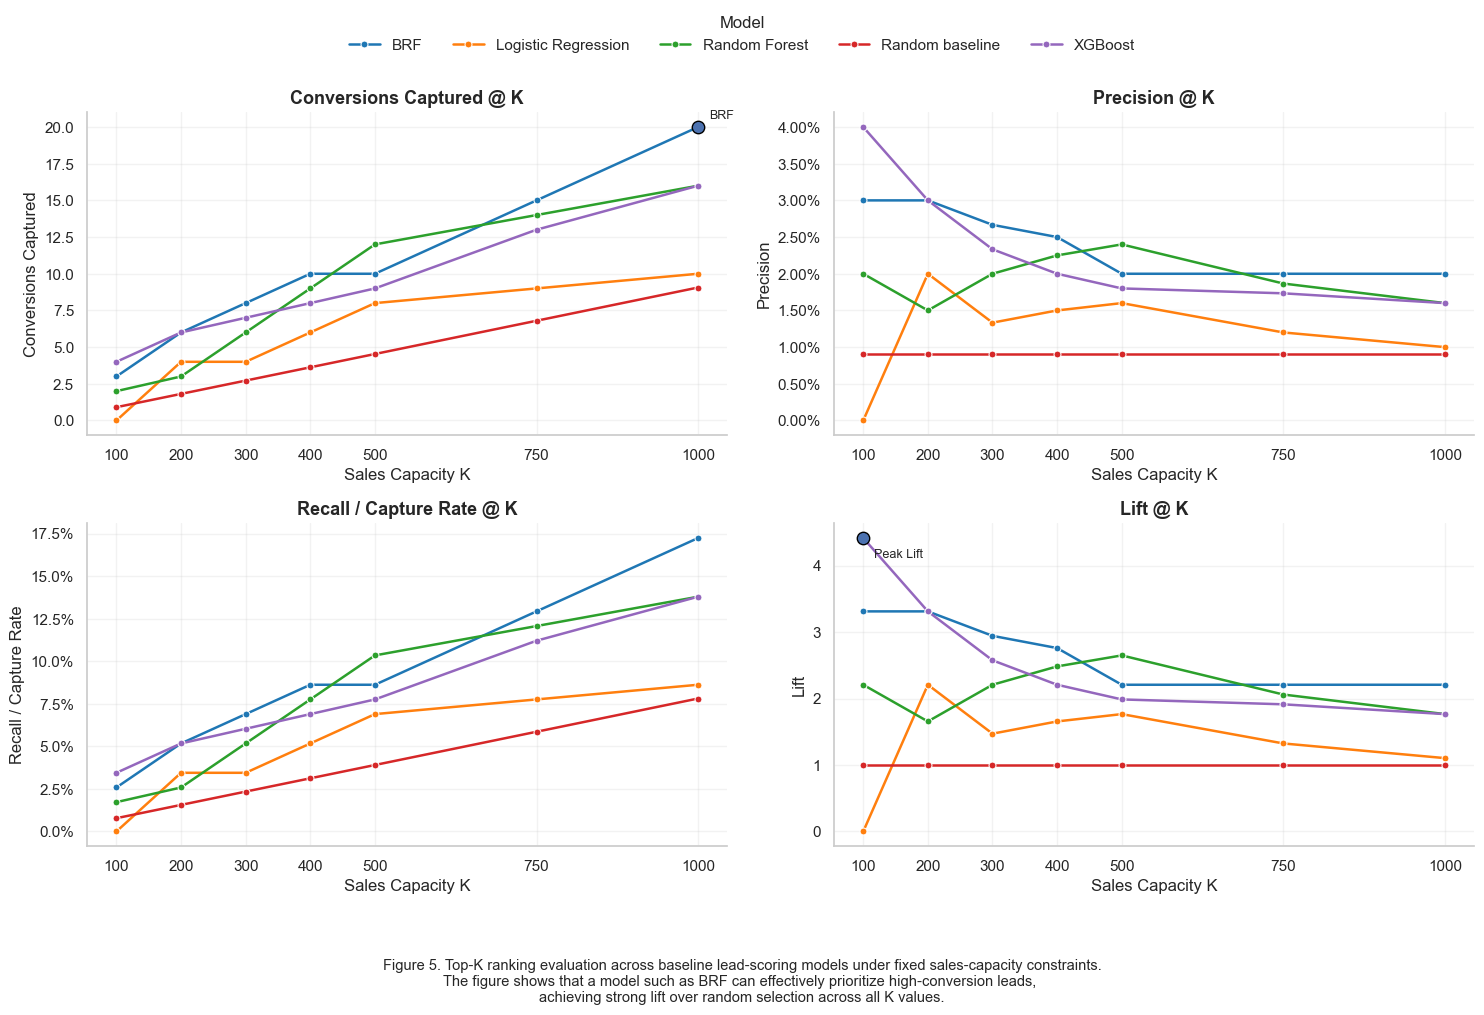

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==========================================
# Theme
# ==========================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plot_df = (
    top_k_metrics_df
    .copy()
    .sort_values(["model", "K"])
)

# ==========================================
# Figure
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=False
)

palette = sns.color_palette(
    "tab10",
    n_colors=plot_df["model"].nunique()
)

common_kwargs = dict(
    data=plot_df,
    x="K",
    hue="model",
    marker="o",
    linewidth=1.8,
    markersize=5,
    palette=palette
)

# ==========================================
# Conversions @ K
# ==========================================

ax = axes[0, 0]

sns.lineplot(
    y="conversions_at_K",
    ax=ax,
    **common_kwargs
)

best_conv = plot_df.loc[
    plot_df["conversions_at_K"].idxmax()
]

ax.scatter(
    best_conv["K"],
    best_conv["conversions_at_K"],
    s=80,
    edgecolor="black",
    linewidth=1,
    zorder=5
)

ax.annotate(
    best_conv["model"],
    xy=(best_conv["K"], best_conv["conversions_at_K"]),
    xytext=(8, 6),
    textcoords="offset points",
    fontsize=9
)

ax.set_title(
    "Conversions Captured @ K",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Conversions Captured")
ax.set_xlabel("Sales Capacity K")

# ==========================================
# Precision @ K
# ==========================================

ax = axes[0, 1]

sns.lineplot(
    y="precision_at_K",
    legend=False,
    ax=ax,
    **common_kwargs
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_title(
    "Precision @ K",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Precision")
ax.set_xlabel("Sales Capacity K")

# ==========================================
# Recall @ K
# ==========================================

ax = axes[1, 0]

sns.lineplot(
    y="recall_at_K",
    legend=False,
    ax=ax,
    **common_kwargs
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_title(
    "Recall / Capture Rate @ K",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Recall / Capture Rate")
ax.set_xlabel("Sales Capacity K")

# ==========================================
# Lift @ K
# ==========================================

ax = axes[1, 1]

sns.lineplot(
    y="lift_at_K",
    legend=False,
    ax=ax,
    **common_kwargs
)

best_lift = plot_df.loc[
    plot_df["lift_at_K"].idxmax()
]

ax.scatter(
    best_lift["K"],
    best_lift["lift_at_K"],
    s=80,
    edgecolor="black",
    linewidth=1,
    zorder=5
)

ax.annotate(
    "Peak Lift",
    xy=(best_lift["K"], best_lift["lift_at_K"]),
    xytext=(8, -14),
    textcoords="offset points",
    fontsize=9
)

ax.set_title(
    "Lift @ K",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Lift")
ax.set_xlabel("Sales Capacity K")

# ==========================================
# Shared formatting
# ==========================================

for ax in axes.flat:

    ax.set_xticks(
        sorted(plot_df["K"].unique())
    )

    ax.grid(
        alpha=0.25
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================================
# Shared legend
# ==========================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=min(len(labels), 5),
    frameon=False
)

axes[0, 0].legend_.remove()

# ==========================================
# Caption
# ==========================================

fig.text(
    0.5,
    0.01,
    (
        "Figure 5. Top-K ranking evaluation across baseline lead-scoring models under fixed sales-capacity constraints.\n"
        "The figure shows that a model such as BRF can effectively prioritize high-conversion leads, \n"
        "achieving strong lift over random selection across all K values."
    ),
    ha="center",
    fontsize=10.5
)

# ==========================================
# Layout
# ==========================================

plt.tight_layout(
    rect=[0, 0.1, 1, 0.94]
)

plt.show()

### Observations (Figure 5)


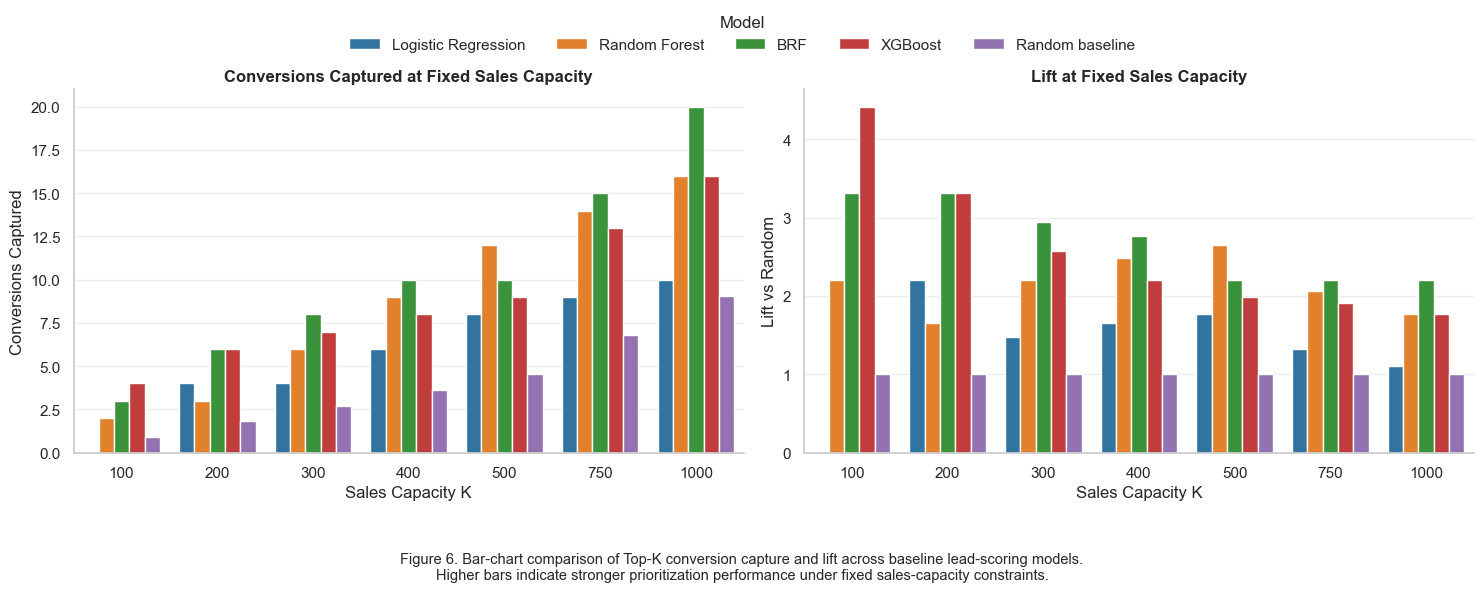

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Theme
# ==========================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# ==========================================
# Figure
# ==========================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5)
)

palette = sns.color_palette(
    "tab10",
    n_colors=top_k_metrics_df["model"].nunique()
)

# ==========================================
# Conversions @ K
# ==========================================

sns.barplot(
    data=top_k_metrics_df,
    x="K",
    y="conversions_at_K",
    hue="model",
    palette=palette,
    ax=axes[0],
)

axes[0].set_title(
    "Conversions Captured at Fixed Sales Capacity",
    fontsize=12,
    weight="bold"
)

axes[0].set_xlabel("Sales Capacity K")
axes[0].set_ylabel("Conversions Captured")

# ==========================================
# Lift @ K
# ==========================================

sns.barplot(
    data=top_k_metrics_df,
    x="K",
    y="lift_at_K",
    hue="model",
    palette=palette,
    ax=axes[1],
)

axes[1].set_title(
    "Lift at Fixed Sales Capacity",
    fontsize=12,
    weight="bold"
)

axes[1].set_xlabel("Sales Capacity K")
axes[1].set_ylabel("Lift vs Random")

# ==========================================
# Shared formatting
# ==========================================

for ax in axes:

    ax.grid(
        True,
        axis="y",
        alpha=0.35
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================================
# Shared legend
# ==========================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(labels), 5),
    frameon=False
)

axes[0].legend_.remove()
axes[1].legend_.remove()

# ==========================================
# Caption
# ==========================================

fig.text(
    0.5,
    -0.03,
    (
        "Figure 6. Bar-chart comparison of Top-K conversion capture and lift across baseline lead-scoring models.\n"
        "Higher bars indicate stronger prioritization performance under fixed sales-capacity constraints."
    ),
    ha="center",
    fontsize=10.5
)

# ==========================================
# Layout
# ==========================================

plt.tight_layout(
    rect=[0, 0.08, 1, 0.93]
)

plt.show()

### Observations (Figure 6)


In [24]:
def bootstrap_precision_at_k(
    df,
    score_col,
    k,
    target_col=TARGET_COL,
    n_bootstrap=500,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)

    deltas = []
    base_rate = df[target_col].mean()

    for _ in range(n_bootstrap):
        sample = df.sample(
            n=len(df),
            replace=True,
            random_state=int(rng.integers(1e9)),
        )

        top_k = sample.nlargest(k, score_col)

        model_precision = top_k[target_col].mean()
        random_precision = base_rate

        deltas.append(model_precision - random_precision)

    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])

    return {
        "ci_low": ci_low,
        "ci_high": ci_high,
        "mean_delta": np.mean(deltas),
    }


bootstrap_rows = []

for model_name, score_col in SCORE_COLS.items():
    for k in K_VALUES:
        result = bootstrap_precision_at_k(
            results_df,
            score_col=score_col,
            k=k,
        )

        bootstrap_rows.append({
            "model": model_name,
            "k": k,
            "mean_delta_precision": result["mean_delta"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)

display(bootstrap_df)

,model,k,mean_delta_precision,ci_low,ci_high
0,Logistic Regression,100,-0.009042,-0.009062,-0.009062
1,Logistic Regression,200,0.008218,-0.009062,0.025938
2,Logistic Regression,300,0.005644,-0.005729,0.017604
3,Logistic Regression,400,0.006293,-0.004062,0.020937
4,Logistic Regression,500,0.006706,-0.003062,0.018938
5,Logistic Regression,750,0.002802,-0.003729,0.010938
6,Logistic Regression,1000,0.000886,-0.005062,0.006938
7,Random Forest,100,0.009837,-0.009062,0.040938
8,Random Forest,200,0.005687,-0.009062,0.025938
9,Random Forest,300,0.010271,-0.002396,0.027604


In [25]:
X_train

,log_history,recency,spend_level,log_history_x_recency,newbie_x_log_history,mens,womens,newbie,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level
63253,3.433665,1,1.0,3.433665,0.000000,0,1,0,0,1,0,Web,Urban,Web_Urban,Web_level_1.0
22434,3.972742,8,1.0,31.781934,0.000000,1,0,0,1,0,0,Phone,Surburban,Phone_Surburban,Phone_level_1.0
506,4.469694,9,1.0,40.227247,0.000000,1,0,0,1,0,0,Web,Surburban,Web_Surburban,Web_level_1.0
10662,4.452136,11,1.0,48.973491,4.452136,1,0,1,1,0,0,Web,Surburban,Web_Surburban,Web_level_1.0
48643,4.685551,9,2.0,42.169962,0.000000,0,1,0,0,1,0,Phone,Surburban,Phone_Surburban,Phone_level_2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20710,4.989888,2,2.0,9.979776,4.989888,0,1,1,0,1,0,Web,Surburban,Web_Surburban,Web_level_2.0
22843,5.980783,11,4.0,65.788610,5.980783,1,0,1,1,0,0,Web,Surburban,Web_Surburban,Web_level_4.0
21532,3.853334,3,1.0,11.560002,0.000000,1,0,0,1,0,0,Web,Urban,Web_Urban,Web_level_1.0
8735,6.291050,5,5.0,31.455252,6.291050,1,0,1,1,0,0,Phone,Urban,Phone_Urban,Phone_level_5.0


## Top-K Profile Analysis

This diagnostic explains what kinds of leads each model is prioritizing. It compares feature averages inside each model's top K list against the full test set.

This is useful for spotting ranking concentration, for example if one model heavily favors high-history customers or a narrow channel/zip segment.

In [26]:
PROFILE_K = 500

profile_rows = []
profile_numeric_cols = [
    # "history",
    "log_history",
    "recency",
    "spend_level",
    "mens",
    "womens",
    "newbie",
    "mens_only",
    "womens_only",
    "mens_womens_both",
]

baseline_profile = results_df[profile_numeric_cols].mean()

for model_name, score_col in SCORE_COLS.items():
    top_k = results_df.sort_values(score_col, ascending=False).head(PROFILE_K)
    top_profile = top_k[profile_numeric_cols].mean()

    for feature in profile_numeric_cols:
        profile_rows.append(
            {
                "model": model_name,
                "feature": feature,
                "top_k_mean": top_profile[feature],
                "test_mean": baseline_profile[feature],
                "difference": top_profile[feature] - baseline_profile[feature],
            }
        )

profile_df = pd.DataFrame(profile_rows)

display(profile_df.sort_values(["model", "difference"], ascending=[True, False]).round(4))

,model,feature,top_k_mean,test_mean,difference
20,BRF,spend_level,4.5340,2.4955,2.0385
18,BRF,log_history,6.2065,5.0152,1.1913
26,BRF,mens_womens_both,0.4120,0.0984,0.3136
22,BRF,womens,0.7280,0.5439,0.1841
21,BRF,mens,0.6840,0.5545,0.1295
23,BRF,newbie,0.4520,0.5030,-0.0510
25,BRF,womens_only,0.3160,0.4455,-0.1295
24,BRF,mens_only,0.2720,0.4561,-0.1841
19,BRF,recency,1.8040,5.7630,-3.9590
2,Logistic Regression,spend_level,5.4800,2.4955,2.9845


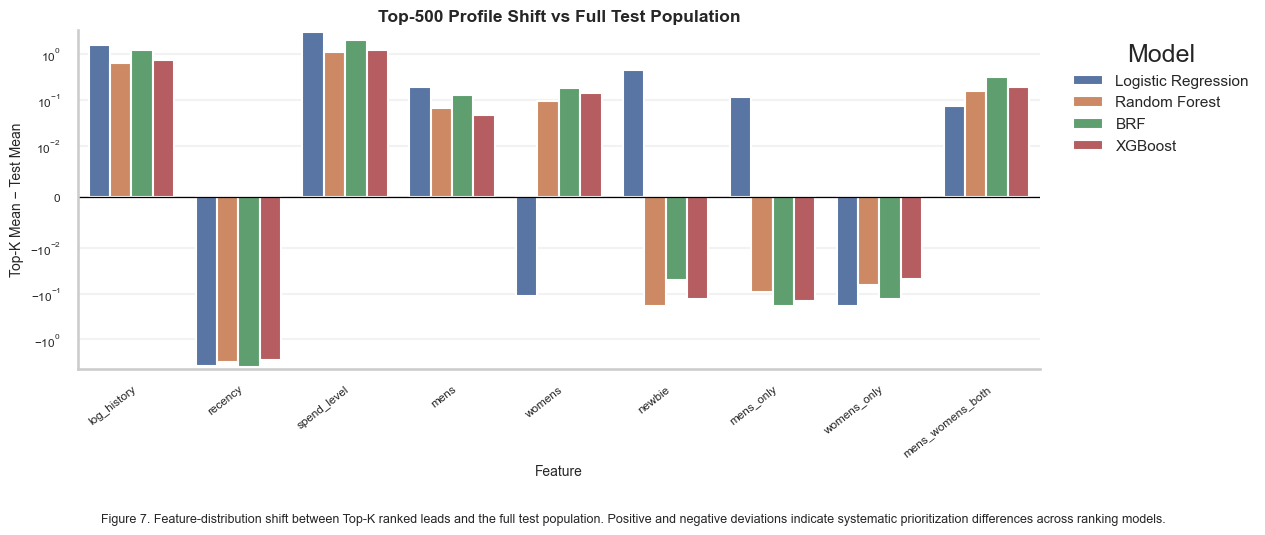

In [44]:
# =========================================================
# FEATURE PROFILE SHIFT PLOT
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 5.5)
)

sns.barplot(
    data=profile_df,
    x="feature",
    y="difference",
    hue="model",
    ax=ax,
)

# =========================================================
# SCALE
# =========================================================

ax.set_yscale(
    "symlog",
    linthresh=0.01
)

# =========================================================
# REFERENCE LINE
# =========================================================

ax.axhline(
    0,
    color="black",
    linewidth=0.9
)

# =========================================================
# TITLES
# =========================================================

ax.set_title(
    f"Top-{PROFILE_K} Profile Shift vs Full Test Population",
    fontsize=12.5,
    weight="bold",
    pad=6,
)

ax.set_ylabel(
    "Top-K Mean − Test Mean",
    fontsize=10,
    labelpad=4,
)

ax.set_xlabel(
    "Feature",
    fontsize=10,
    labelpad=4,
)

# =========================================================
# X LABELS
# =========================================================

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=38,
    ha="right",
    rotation_mode="anchor",
    fontsize=8.5,
)

ax.tick_params(
    axis="x",
    pad=2,
)

ax.tick_params(
    axis="y",
    labelsize=8.5,
)

# =========================================================
# GRID / SPINES
# =========================================================

ax.grid(
    True,
    axis="y",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# LEGEND
# =========================================================

ax.legend(
    title="Model",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

# =========================================================
# CAPTION
# =========================================================

fig.text(
    0.5,
    -0.001,
    (
        "Figure 7. Feature-distribution shift between Top-K ranked leads and the full test population. "
        "Positive and negative deviations indicate systematic prioritization differences across ranking models."
    ),
    ha="center",
    fontsize=9,
)

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0.03, 1, 0.98]
)

plt.show()

### Observations (Figure 7): Feature Ablation and Model Behavior

After removing the `raw_history` feature and the `history × recency` interaction term, the behavior of the models diverged significantly.

- Logistic Regression performance degraded and the selected Top-K population became noticeably less stable.
- Tree-based models (`Random Forest`, `Balanced Random Forest`, `XGBoost`) slightly improved in ranking performance.

This suggests that the removed behavioral-history features played different roles across model families.

For Logistic Regression, the removed features provided important explicitly engineered behavioral structure:

$$
P(Y = 1 \mid X)
\approx
\beta_0
+
\beta_1 \cdot \text{history}
+
\beta_2 \cdot \text{recency}
+
\beta_3 \cdot (\text{history} \times \text{recency})
$$
Without these interaction-aware signals, the linear model began relying more heavily on weaker proxy variables such as:
- spend level
- demographic/category indicators
- newbie status

As a result:
- Top-K segment composition became less stable
- feature importance redistributed aggressively
- selection drift increased

In contrast, tree-based models were able to recover nonlinear interactions implicitly through hierarchical splitting. Removing the dominant history-related features appears to have reduced shortcut-like behavior and forced trees to discover richer interaction structure across the remaining features.

This produced:
- improved ranking diversity
- better interaction discovery
- slightly stronger Top-K performance

The experiment suggests that dominant behavioral-intent features can simultaneously:
- stabilize linear models
- over-concentrate tree-based ranking policies

This creates an important tradeoff between:
- predictive strength
- ranking diversity
- long-term selection stability
- proxy dependence



In [29]:
top_k_segment_rows = []

for model_name, score_col in SCORE_COLS.items():
    top_k = results_df.sort_values(score_col, ascending=False).head(PROFILE_K)

    for col in ["channel", "zip_code", "channel_zip_code", "channel_spend_level"]:
        shares = top_k[col].value_counts(normalize=True).rename("top_k_share")
        base_shares = results_df[col].value_counts(normalize=True).rename("test_share")
        joined = pd.concat([shares, base_shares], axis=1).fillna(0).reset_index()
        joined.columns = ["level", "top_k_share", "test_share"]
        joined["difference"] = joined["top_k_share"] - joined["test_share"]
        joined["feature"] = col
        joined["model"] = model_name
        top_k_segment_rows.append(joined)

segment_profile_df = pd.concat(top_k_segment_rows, ignore_index=True)

display(
    segment_profile_df
    .sort_values(["model", "feature", "difference"], ascending=[True, True, False])
    .groupby(["model", "feature"])
    .head(5)
    .round(4)
)

,level,top_k_share,test_share,difference,feature,model
69,Multichannel,0.328,0.1245,0.2035,channel,BRF
68,Web,0.436,0.4420,-0.0060,channel,BRF
70,Phone,0.236,0.4335,-0.1975,channel,BRF
83,Multichannel_level_4.0,0.176,0.0324,0.1436,channel_spend_level,BRF
85,Phone_level_7.0,0.106,0.0073,0.0987,channel_spend_level,BRF
...,...,...,...,...,...,...
114,Phone_Rural,0.078,0.0649,0.0131,channel_zip_code,XGBoost
108,Web_Urban,0.184,0.1727,0.0113,channel_zip_code,XGBoost
107,Rural,0.232,0.1498,0.0822,zip_code,XGBoost
105,Urban,0.398,0.3995,-0.0015,zip_code,XGBoost


## Lift Curve

The lift curve compares model ranking against random selection at every cutoff K.

Lift at K is:

`precision_at_K / base_conversion_rate`

A lift of 3 means the selected top-K leads convert three times better than random leads. The plot below focuses on the top 20 percent because that is where sales-capacity decisions usually happen.

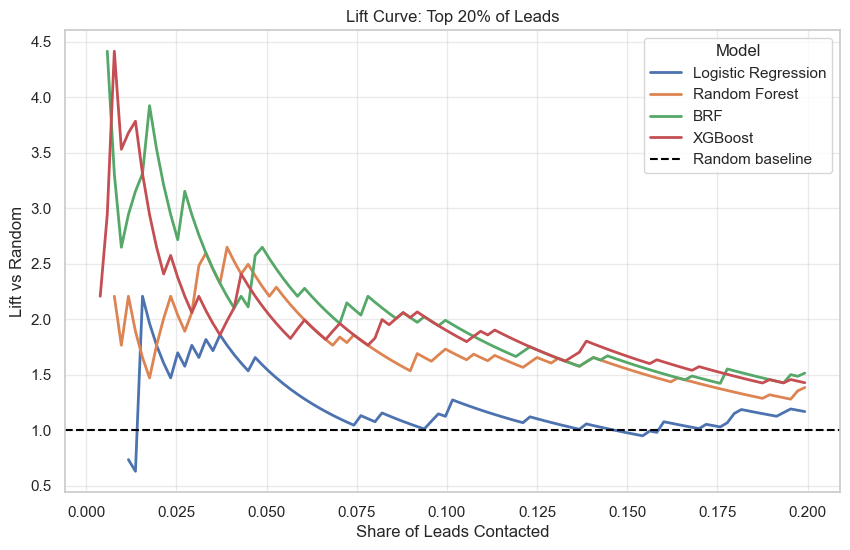

In [30]:
def make_lift_curve_df(df, score_cols, target_col=TARGET_COL):
    rows = []
    base_rate = df[target_col].mean()
    n = len(df)

    for model_name, score_col in score_cols.items():
        ranked = (
            df[[target_col, score_col]]
            .sort_values(score_col, ascending=False)
            .reset_index(drop=True)
        )

        ranked["rank"] = np.arange(1, n + 1)
        ranked["cum_conversions"] = ranked[target_col].cumsum()
        ranked["share_of_leads_contacted"] = ranked["rank"] / n
        ranked["precision_at_k"] = ranked["cum_conversions"] / ranked["rank"]
        ranked["lift_at_k"] = ranked["precision_at_k"] / base_rate
        ranked["model"] = model_name

        rows.append(
            ranked[
                [
                    "model",
                    "rank",
                    "share_of_leads_contacted",
                    "precision_at_k",
                    "lift_at_k",
                ]
            ]
        )

    return pd.concat(rows, ignore_index=True)


lift_df = make_lift_curve_df(results_df, SCORE_COLS)

top_20_lift_df = (
    lift_df[
        (lift_df["share_of_leads_contacted"] <= 0.20)
        & (lift_df["lift_at_k"] > 0)
    ]
    .query("rank == 1 or rank % 25 == 0")
    .copy()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=top_20_lift_df,
    x="share_of_leads_contacted",
    y="lift_at_k",
    hue="model",
    linewidth=2,
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)

plt.title("Lift Curve: Top 20% of Leads")
plt.xlabel("Share of Leads Contacted")
plt.ylabel("Lift vs Random")
plt.grid(True, alpha=0.4)
plt.legend(title="Model")
plt.show()

## PR-AUC and ROC-AUC Summary

PR-AUC is especially important here because the positive class is rare.

- PR-AUC summarizes precision-recall performance across thresholds.
- A random model has expected PR-AUC close to the base conversion rate.
- ROC-AUC measures broad rank separation between converters and non-converters, but it can look optimistic on imbalanced data.

In [31]:
summary_rows = []

for model_name, score_col in SCORE_COLS.items():
    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    summary_rows.append(
        {
            "model": model_name,
            "PR_AUC_average_precision": pr_auc,
            "ROC_AUC": roc_auc,
        }
    )

ranking_summary_df = pd.DataFrame(summary_rows)
ranking_summary_df["base_conversion_rate"] = results_df[TARGET_COL].mean()
ranking_summary_df["PR_AUC_lift_over_random"] = (
    ranking_summary_df["PR_AUC_average_precision"]
    / ranking_summary_df["base_conversion_rate"]
)

display(
    ranking_summary_df
    .sort_values("PR_AUC_average_precision", ascending=False)
    .round(4)
)

,model,PR_AUC_average_precision,ROC_AUC,base_conversion_rate,PR_AUC_lift_over_random
2,BRF,0.0147,0.6072,0.0091,1.6191
3,XGBoost,0.0133,0.5463,0.0091,1.4669
1,Random Forest,0.0126,0.5757,0.0091,1.3930
0,Logistic Regression,0.0104,0.5300,0.0091,1.1527


## Cumulative Gains Curve

The cumulative gains curve shows how quickly each ranking captures actual converters.

Each point corresponds to one cutoff K:

- x-axis: K divided by total test leads
- y-axis: conversions in top K divided by total test conversions

A higher curve near the start means converters appear earlier in the ranked list.

## Precision-Recall Curve

The precision-recall curve evaluates each possible score threshold.

- Precision: among selected leads, what share converted?
- Recall: among all converters, what share did we select?

As the threshold gets lower, recall usually rises and precision usually falls.

## ROC Curve

The ROC curve shows the tradeoff between true positive rate and false positive rate across thresholds.

ROC-AUC can be useful as a broad ranking measure, but for this rare-conversion problem it should be secondary to PR-AUC and top-K lift.

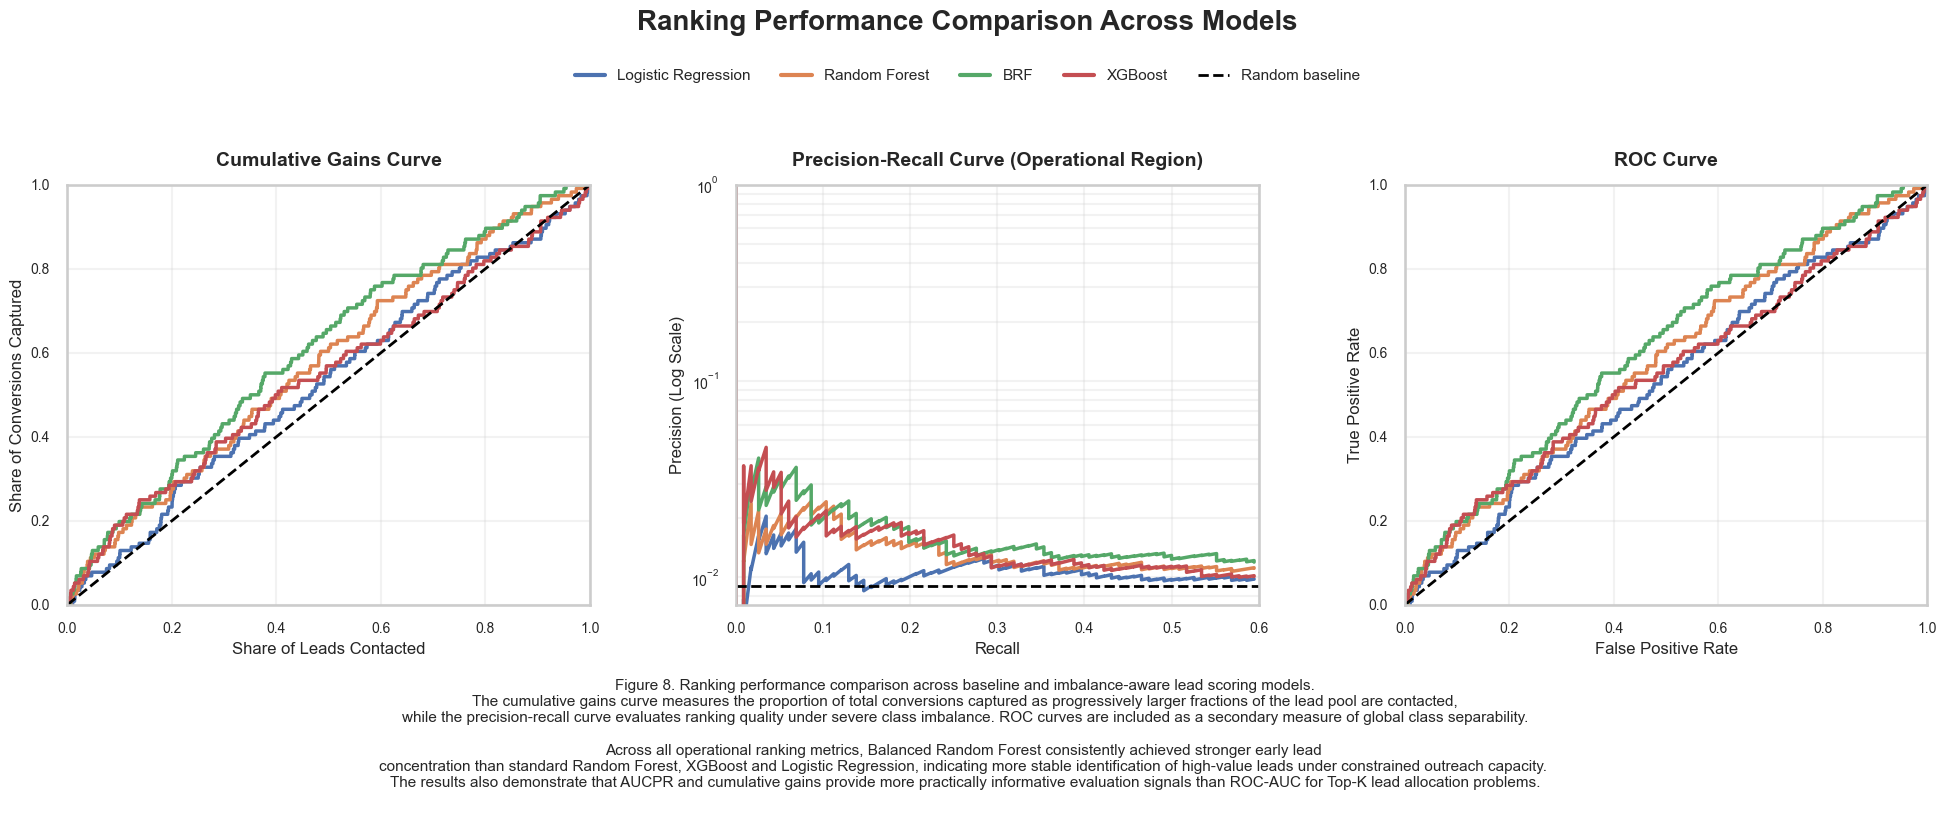

In [47]:
# =========================================================
# CUMULATIVE GAINS DATA
# =========================================================

def make_cumulative_gains_df(
    df,
    score_cols,
    target_col=TARGET_COL,
):

    rows = []

    total_conversions = df[target_col].sum()
    n = len(df)

    for model_name, score_col in score_cols.items():

        ranked = (
            df[[target_col, score_col]]
            .sort_values(score_col, ascending=False)
            .reset_index(drop=True)
        )

        ranked["rank"] = np.arange(1, n + 1)

        ranked["cum_conversions"] = (
            ranked[target_col]
            .cumsum()
        )

        ranked["share_of_leads_contacted"] = (
            ranked["rank"] / n
        )

        ranked["share_of_conversions_captured"] = (
            ranked["cum_conversions"] / total_conversions
        )

        ranked["model"] = model_name

        rows.append(
            ranked[
                [
                    "model",
                    "share_of_leads_contacted",
                    "share_of_conversions_captured",
                ]
            ]
        )

    random_curve = pd.DataFrame({
        "model": "Random baseline",
        "share_of_leads_contacted": [0, 1],
        "share_of_conversions_captured": [0, 1],
    })

    return pd.concat(
        rows + [random_curve],
        ignore_index=True,
    )


gains_df = make_cumulative_gains_df(
    results_df,
    SCORE_COLS,
)

# =========================================================
# GLOBAL STYLE
# =========================================================

sns.set_theme(
    style="whitegrid",
    context="talk",
)

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# =========================================================
# FIGURE + SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
)

# =========================================================
# COLOR PALETTE
# =========================================================

palette = sns.color_palette("deep", n_colors=len(SCORE_COLS))

model_colors = {
    model: palette[i]
    for i, model in enumerate(SCORE_COLS.keys())
}

# =========================================================
# 1. CUMULATIVE GAINS CURVE
# =========================================================

ax = axes[0]

for model_name in SCORE_COLS.keys():

    subset = gains_df.query("model == @model_name")

    ax.plot(
        subset["share_of_leads_contacted"],
        subset["share_of_conversions_captured"],
        linewidth=2.5,
        label=model_name,
        color=model_colors[model_name],
    )

# Random baseline
random_subset = gains_df.query("model == 'Random baseline'")

ax.plot(
    random_subset["share_of_leads_contacted"],
    random_subset["share_of_conversions_captured"],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Random baseline",
)

ax.set_title(
    "Cumulative Gains Curve",
    pad=14,
    weight="bold",
)

ax.set_xlabel("Share of Leads Contacted")
ax.set_ylabel("Share of Conversions Captured")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.25)

# =========================================================
# 2. PRECISION-RECALL CURVE (READABILITY IMPROVED)
# =========================================================

ax = axes[1]

base_rate = results_df[TARGET_COL].mean()

for model_name, score_col in SCORE_COLS.items():

    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_score,
    )

    pr_auc = average_precision_score(
        y_true,
        y_score,
    )

    # -----------------------------------------------------
    # READABILITY TRANSFORM
    # -----------------------------------------------------
    #
    # Most useful ranking behavior occurs at:
    # high precision + low recall.
    #
    # Restricting the view improves visibility of
    # operationally important regions.
    #
    # -----------------------------------------------------

    mask = recall <= 0.60

    ax.plot(
        recall[mask],
        precision[mask],
        linewidth=2.5,
        label=f"{model_name} ({pr_auc:.4f})",
        color=model_colors[model_name],
    )

ax.axhline(
    y=base_rate,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline ({base_rate:.4f})",
)

# ---------------------------------------------------------
# LOG-SCALE PRECISION AXIS
# ---------------------------------------------------------
#
# Makes separation between low precision values visible.
#
# Very useful in imbalanced datasets where:
# 0.01 vs 0.03 precision matters substantially.
#
# ---------------------------------------------------------

ax.set_yscale("log")

ax.set_title(
    "Precision-Recall Curve (Operational Region)",
    pad=14,
    weight="bold",
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision (Log Scale)")

ax.set_xlim(0, 0.60)

# Optional:
# adjust depending on your dataset prevalence
ax.set_ylim(
    max(base_rate * 0.8, 0.001),
    1.0,
)

ax.grid(
    True,
    alpha=0.25,
    which="both",
)

# =========================================================
# 3. ROC CURVE
# =========================================================

ax = axes[2]

for model_name, score_col in SCORE_COLS.items():

    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    fpr, tpr, _ = roc_curve(
        y_true,
        y_score,
    )

    roc_auc = roc_auc_score(
        y_true,
        y_score,
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} ({roc_auc:.4f})",
        color=model_colors[model_name],
    )

ax.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Random baseline",
)

ax.set_title(
    "ROC Curve",
    pad=14,
    weight="bold",
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.25)

# =========================================================
# REMOVE LOCAL LEGENDS
# =========================================================

for ax in axes:

    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    "Ranking Performance Comparison Across Models",
    fontsize=20,
    fontweight="bold",
    y=1.03,
)

# =========================================================
# GLOBAL LEGEND (TOP CENTER)
# =========================================================

handles = [
    plt.Line2D(
        [0],
        [0],
        color=model_colors[m],
        lw=3,
    )
    for m in SCORE_COLS.keys()
]

labels = list(SCORE_COLS.keys())

handles.append(
    plt.Line2D(
        [0],
        [0],
        color="black",
        lw=2,
        linestyle="--",
    )
)

labels.append("Random baseline")

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(labels),
    frameon=False,
    fontsize=11,
)

# =========================================================
# CAPTION
# =========================================================

caption = (
    "Figure 8. Ranking performance comparison across baseline and imbalance-aware lead scoring models. \n"
    "The cumulative gains curve measures the proportion of total conversions captured as progressively larger fractions of the lead pool are contacted, \n"
    "while the precision-recall curve evaluates ranking quality under severe class imbalance. ROC curves are included as a secondary measure of global class separability. \n\n"
    "Across all operational ranking metrics, Balanced Random Forest consistently achieved stronger early lead  \n"
    "concentration than standard Random Forest, XGBoost and Logistic Regression, indicating more stable identification of high-value leads under constrained outreach capacity.  \n"
    "The results also demonstrate that AUCPR and cumulative gains provide more practically informative evaluation signals than ROC-AUC for Top-K lead allocation problems. \n"
)

fig.text(
    0.5,
    -0.1,
    caption,
    ha="center",
    fontsize=11,
    wrap=True,
)

# =========================================================
# SPACING
# =========================================================

plt.subplots_adjust(
    top=0.78,
    bottom=0.18,
    wspace=0.28,
)

plt.show()

In [33]:
# =========================================================
# E01 RESULTS TABLE
# =========================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)


# ---------------------------------------------------------
# RANDOM BASELINE
# ---------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)

results_rows = []

base_rate = y_test.mean()

# =========================================================
# TOP-K METRIC FUNCTION
# =========================================================

def compute_topk_metrics(
    y_true,
    scores,
    k,
):

    order = np.argsort(scores)[::-1]
    top_idx = order[:k]

    y_top = y_true.iloc[top_idx]

    precision_at_k = y_top.mean()

    recall_at_k = (
        y_top.sum()
        / y_true.sum()
    )

    lift_at_k = (
        precision_at_k
        / y_true.mean()
    )

    conversions_captured = y_top.sum()

    return {
        "Precision@B": precision_at_k,
        "Recall@B": recall_at_k,
        "Lift@B": lift_at_k,
        "ConversionsCaptured@B": conversions_captured,
    }

# =========================================================
# RANDOM BASELINE RESULTS
# =========================================================

for k in K_VALUES:

    random_scores = rng.random(len(y_test))

    random_metrics = compute_topk_metrics(
        y_test,
        random_scores,
        k,
    )

    results_rows.append({

        "Model": "Random",
        "B": k,

        **random_metrics,

        "AUCPR": np.nan,
        "ROC-AUC": np.nan,

        "PositiveRate": base_rate,
    })

# =========================================================
# MODEL RESULTS
# =========================================================

for model_name, pipeline in pipelines.items():

    # ---------------------------------------------
    # PREDICTIONS
    # ---------------------------------------------

    y_pred = pipeline.predict(X_test)

    y_proba = (
        pipeline
        .predict_proba(X_test)[:, 1]
    )

    # ---------------------------------------------
    # GLOBAL METRICS
    # ---------------------------------------------

    aucpr = average_precision_score(
        y_test,
        y_proba,
    )

    rocauc = roc_auc_score(
        y_test,
        y_proba,
    )

    threshold_precision = precision_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    threshold_recall = recall_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    threshold_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    # ---------------------------------------------
    # TOP-K METRICS
    # ---------------------------------------------

    for k in K_VALUES:

        topk_metrics = compute_topk_metrics(
            y_test,
            y_proba,
            k,
        )

        results_rows.append({

            "Model": model_name,
            "B": k,

            **topk_metrics,

            # ---------------------------------
            # GLOBAL RANKING METRICS
            # ---------------------------------

            "AUCPR": aucpr,
            "ROC-AUC": rocauc,

            # ---------------------------------
            # THRESHOLD METRICS
            # ---------------------------------

            "ThresholdPrecision": threshold_precision,
            "ThresholdRecall": threshold_recall,
            "ThresholdF1": threshold_f1,

            # ---------------------------------
            # BASELINE CONTEXT
            # ---------------------------------

            "PositiveRate": base_rate,
        })

# =========================================================
# RESULTS DATAFRAME
# =========================================================

E01_results = pd.DataFrame(results_rows)

# =========================================================
# ROUNDING
# =========================================================

metric_cols = [

    "Precision@B",
    "Recall@B",
    "Lift@B",

    "AUCPR",
    "ROC-AUC",

    "ThresholdPrecision",
    "ThresholdRecall",
    "ThresholdF1",

    "PositiveRate",
]

E01_results[metric_cols] = (
    E01_results[metric_cols]
    .round(4)
)

# =========================================================
# SORTING
# =========================================================

E01_results = (
    E01_results
    .sort_values(
        ["B", "Precision@B"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# =========================================================
# SAVE CSV
# =========================================================
RESULTS_DIR = Path(BASE_DIR) / "src" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

E01_results.to_csv(
    RESULTS_DIR / "E01_results.csv",
    index=False,
)

# =========================================================
# DISPLAY
# =========================================================

E01_results.head(20)

,Model,B,Precision@B,Recall@B,Lift@B,ConversionsCaptured@B,AUCPR,ROC-AUC,PositiveRate,ThresholdPrecision,ThresholdRecall,ThresholdF1
0,XGBoost,100,0.0400,0.0345,4.4138,4,0.0133,0.5463,0.0091,0.0131,0.2845,0.0251
1,BRF,100,0.0300,0.0259,3.3103,3,0.0147,0.6072,0.0091,0.0132,0.4828,0.0256
2,Random Forest,100,0.0200,0.0172,2.2069,2,0.0126,0.5757,0.0091,0.0187,0.1207,0.0324
3,Random,100,0.0000,0.0000,0.0000,0,NaN,NaN,0.0091,NaN,NaN,NaN
4,Logistic Regression,100,0.0000,0.0000,0.0000,0,0.0104,0.5300,0.0091,0.0114,0.3276,0.0220
5,BRF,200,0.0300,0.0517,3.3103,6,0.0147,0.6072,0.0091,0.0132,0.4828,0.0256
6,XGBoost,200,0.0300,0.0517,3.3103,6,0.0133,0.5463,0.0091,0.0131,0.2845,0.0251
7,Logistic Regression,200,0.0200,0.0345,2.2069,4,0.0104,0.5300,0.0091,0.0114,0.3276,0.0220
8,Random Forest,200,0.0150,0.0259,1.6552,3,0.0126,0.5757,0.0091,0.0187,0.1207,0.0324
9,Random,200,0.0050,0.0086,0.5517,1,NaN,NaN,0.0091,NaN,NaN,NaN


In [34]:
# =========================================================
# E01 BENCHMARK RESULTS TABLE
# =========================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

# =========================================================
# CONFIG
# =========================================================


rng = np.random.default_rng(RANDOM_STATE)

base_rate = y_test.mean()

results_rows = []

# =========================================================
# TOP-K METRICS
# =========================================================
# =========================================================
# TOP-K METRICS
# =========================================================

def compute_topk_metrics(
    y_true,
    scores,
    k,
):

    order = np.argsort(scores)[::-1]

    top_idx = order[:k]

    y_top = y_true.iloc[top_idx]

    converters_in_top_b = int(y_top.sum())

    non_converters_in_top_b = int(
        len(y_top) - converters_in_top_b
    )

    precision_at_k = y_top.mean()

    recall_at_k = (
        y_top.sum()
        / y_true.sum()
    )

    lift_at_k = (
        precision_at_k
        / y_true.mean()
    )

    conversions_captured = y_top.sum()

    delta_precision_at_k = (
        precision_at_k
        - y_true.mean()
    )

    return {

        # -------------------------------------------------
        # RAW COUNTS
        # -------------------------------------------------

        "Converters@B": converters_in_top_b,

        "NonConverters@B": non_converters_in_top_b,

        "Precision@B": precision_at_k,

        "Recall@B": recall_at_k,

        "Lift@B": lift_at_k,

        "DeltaPrecision@B": delta_precision_at_k,

        "ConversionsCaptured@B": conversions_captured,
    }

# =========================================================
# RANDOM BASELINE
# =========================================================

random_scores_full = rng.random(len(y_test))

random_preds = (
    random_scores_full >= 0.5
).astype(int)

random_aucpr = average_precision_score(
    y_test,
    random_scores_full,
)

random_rocauc = roc_auc_score(
    y_test,
    random_scores_full,
)

random_threshold_precision = precision_score(
    y_test,
    random_preds,
    zero_division=0,
)

random_threshold_recall = recall_score(
    y_test,
    random_preds,
    zero_division=0,
)

random_threshold_f1 = f1_score(
    y_test,
    random_preds,
    zero_division=0,
)

for k in K_VALUES:

    random_scores = rng.random(len(y_test))

    random_metrics = compute_topk_metrics(
        y_test,
        random_scores,
        k,
    )

    results_rows.append({

        # ---------------------------------------------
        # IDENTIFIERS
        # ---------------------------------------------

        "Model": "Random",
        "B": k,

        # ---------------------------------------------
        # TOP-K METRICS
        # ---------------------------------------------

        **random_metrics,

        # ---------------------------------------------
        # GLOBAL METRICS
        # ---------------------------------------------

        "AUCPR": random_aucpr,

        "ROC-AUC": random_rocauc,

        # ---------------------------------------------
        # THRESHOLD METRICS
        # ---------------------------------------------

        "ThresholdPrecision": random_threshold_precision,

        "ThresholdRecall": random_threshold_recall,

        "ThresholdF1": random_threshold_f1,

        # ---------------------------------------------
        # BASELINE CONTEXT
        # ---------------------------------------------

        "PositiveRate": base_rate,
    })

# =========================================================
# MODEL RESULTS
# =========================================================

for model_name, pipeline in pipelines.items():

    # -----------------------------------------------------
    # PREDICTIONS
    # -----------------------------------------------------

    y_pred = pipeline.predict(X_test)

    y_proba = (
        pipeline
        .predict_proba(X_test)[:, 1]
    )

    # -----------------------------------------------------
    # GLOBAL RANKING METRICS
    # -----------------------------------------------------

    aucpr = average_precision_score(
        y_test,
        y_proba,
    )

    rocauc = roc_auc_score(
        y_test,
        y_proba,
    )

    # -----------------------------------------------------
    # THRESHOLD METRICS
    # -----------------------------------------------------

    threshold_precision = precision_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    threshold_recall = recall_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    threshold_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    # -----------------------------------------------------
    # TOP-K METRICS
    # -----------------------------------------------------

    for k in K_VALUES:

        topk_metrics = compute_topk_metrics(
            y_test,
            y_proba,
            k,
        )

        results_rows.append({

            # -----------------------------------------
            # IDENTIFIERS
            # -----------------------------------------

            "Model": model_name,

            "B": k,

            # -----------------------------------------
            # TOP-K METRICS
            # -----------------------------------------

            **topk_metrics,

            # -----------------------------------------
            # GLOBAL RANKING METRICS
            # -----------------------------------------

            "AUCPR": aucpr,

            "ROC-AUC": rocauc,

            # -----------------------------------------
            # THRESHOLD METRICS
            # -----------------------------------------

            "ThresholdPrecision": threshold_precision,

            "ThresholdRecall": threshold_recall,

            "ThresholdF1": threshold_f1,

            # -----------------------------------------
            # BASELINE CONTEXT
            # -----------------------------------------

            "PositiveRate": base_rate,
        })

# =========================================================
# RESULTS DATAFRAME
# =========================================================

E01_results = pd.DataFrame(results_rows)

# =========================================================
# ROUNDING
# =========================================================

metric_cols = [
    "Converters@B",
    "NonConverters@B",

    "Precision@B",
    "Recall@B",
    "Lift@B",
    "DeltaPrecision@B",

    "AUCPR",
    "ROC-AUC",

    "ThresholdPrecision",
    "ThresholdRecall",
    "ThresholdF1",

    "PositiveRate",
]

E01_results[metric_cols] = (
    E01_results[metric_cols]
    .round(4)
)

# =========================================================
# SORTING
# =========================================================

E01_results = (
    E01_results
    .sort_values(
        ["B", "Precision@B"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# =========================================================
# DISPLAY
# =========================================================

display(
    E01_results.head(20)
)

# =========================================================
# SAVE CSV
# =========================================================

RESULTS_DIR = Path(BASE_DIR) / "src" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

E01_results.to_csv(
    RESULTS_DIR / "E01_results.csv",
    index=False,
)

print(
    "Saved: E01_results.csv"
)

,Model,B,Converters@B,NonConverters@B,Precision@B,Recall@B,Lift@B,DeltaPrecision@B,ConversionsCaptured@B,AUCPR,ROC-AUC,ThresholdPrecision,ThresholdRecall,ThresholdF1,PositiveRate
0,XGBoost,100,4,96,0.0400,0.0345,4.4138,0.0309,4,0.0133,0.5463,0.0131,0.2845,0.0251,0.0091
1,BRF,100,3,97,0.0300,0.0259,3.3103,0.0209,3,0.0147,0.6072,0.0132,0.4828,0.0256,0.0091
2,Random Forest,100,2,98,0.0200,0.0172,2.2069,0.0109,2,0.0126,0.5757,0.0187,0.1207,0.0324,0.0091
3,Random,100,0,100,0.0000,0.0000,0.0000,-0.0091,0,0.0089,0.5116,0.0091,0.5000,0.0178,0.0091
4,Logistic Regression,100,0,100,0.0000,0.0000,0.0000,-0.0091,0,0.0104,0.5300,0.0114,0.3276,0.0220,0.0091
5,BRF,200,6,194,0.0300,0.0517,3.3103,0.0209,6,0.0147,0.6072,0.0132,0.4828,0.0256,0.0091
6,XGBoost,200,6,194,0.0300,0.0517,3.3103,0.0209,6,0.0133,0.5463,0.0131,0.2845,0.0251,0.0091
7,Logistic Regression,200,4,196,0.0200,0.0345,2.2069,0.0109,4,0.0104,0.5300,0.0114,0.3276,0.0220,0.0091
8,Random Forest,200,3,197,0.0150,0.0259,1.6552,0.0059,3,0.0126,0.5757,0.0187,0.1207,0.0324,0.0091
9,Random,200,0,200,0.0000,0.0000,0.0000,-0.0091,0,0.0089,0.5116,0.0091,0.5000,0.0178,0.0091


Saved: E01_results.csv


## Readout

Use this experiment as the benchmark that later uplift-aware policies must beat.

Recommended interpretation order:

1. Compare top-K lift and conversions captured at realistic sales capacities.
2. Check the early part of the cumulative gains curve.
3. Use PR-AUC as the overall rare-event ranking score.
4. Treat ROC-AUC as a secondary diagnostic.

Important limitation: this notebook ranks observed conversion probability. It does not estimate incremental conversion caused by contact or email treatment.